In [1]:
import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '..')
import codes.toolbox as tb

import warnings
warnings.filterwarnings("ignore")

from importlib import reload
reload(tb)

<module 'codes.toolbox' from '/Users/cfan/Documents/projects/202604_dailyStrategy/notebooks/../codes/toolbox.py'>

In [2]:
dl = tb.DataLoader('../data')
dl

DataLoader(symbols=0GUSDT .. ZRXUSDT (535 symbols), exchanges=(binance, bitget, bybit, okex), instruments=(futures, perps, spot, swap), dates=20250701 .. 20260412 (286 days))

In [3]:
dl.columns

['ts',
 'close',
 'volume_usdt',
 'cvd_usdt',
 'open_interest',
 'funding_rate',
 'funding_interval_hours']

In [4]:
def sigmoid(arr):
    return 1.0/(1.0 + np.exp(-1.0*arr))

def transformY(y, smooth = 0.0):
    if smooth < 1e-8:
        return (np.sign(y)+1.0)/2.0
    return sigmoid(y/smooth)

In [5]:
def showPricePred(price_mat, pred_mat):
    plt.figure(figsize=(12,4))
    for i in range(price_mat.shape[0]):
        plt.subplot(1, 2, 1)
        plt.plot(price_mat[i,:], color = 'grey', alpha = 0.1)
        plt.subplot(1, 2, 2)
        plt.plot(pred_mat[i,:], color = 'grey', alpha = 0.1)
    max_idx = np.arange(len(price_mat[0,]))[price_mat[0] == 1.0]
    plt.subplot(1,2,1)
    plt.title('price')
    plt.plot(np.mean(price_mat, axis = 0), color = 'red')
    plt.axvline(max_idx, color = 'orange', linestyle = 'dashed')
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.title('prediction')
    plt.axhline(0, color = 'black', linestyle = 'dashed')
    plt.axvline(max_idx, color = 'orange', linestyle = 'dashed')
    plt.plot(np.mean(pred_mat, axis = 0), color = 'red')
    plt.grid(True)

def binToDirectionY(ypred, central = 0.5):
    return (ypred-central)*2.0

def plotHistogram(model, X, X_valid, centralize=True):
    ypred_train = model.predict(X)
    ypred_valid = model.predict(X_valid)
    if centralize:
        central = np.median(ypred_train)
        ypred_train = binToDirectionY(ypred_train, central)
        ypred_valid = binToDirectionY(ypred_valid, central)

    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.hist(ypred_train, bins = 100)
    plt.grid(True)
    plt.title('ytrain pred centered')

    plt.subplot(1,2,2)
    plt.hist(ypred_valid, bins = 100)
    plt.grid(True)
    plt.title('yvalid pred centered')

    plt.tight_layout()
    if centralize:
        return central
    return 0
    
def evalModelTrain(model, X_norm, Y, O, cutoff_quantiles, eval_horizon = 'ret_24h', statCol = 2, ypred_trans=None):
    ypred = model.predict(X_norm)
    if ypred_trans is not None:
        ypred = ypred_trans(ypred)

    cutoffs = np.quantile(abs(ypred), cutoff_quantiles)
    cutoff_names = [f"> {int(q*100)}%" for q in cutoff_quantiles]

    tb.MainEvaluateHorizons(ypred, Y, O, cutoffs, eval_horizon = eval_horizon, statCol = statCol, cutoff_names = cutoff_names)


def evalModelValid(model, X_train, X_valid, Y_valid, O_valid, cutoff_quantiles, eval_horizon = 'ret_24h', statCol = 2, ypred_trans=None):
    ytrain_pred = model.predict(X_norm)
    yvalid_pred = model.predict(X_valid)
    if ypred_trans is not None:
        yvalid_pred = ypred_trans(yvalid_pred)
        ytrain_pred = ypred_trans(ytrain_pred)

    cutoffs = np.quantile(abs(ytrain_pred), cutoff_quantiles)
    cutoff_names = [f"> {int(q*100)}%" for q in cutoff_quantiles]

    tb.MainEvaluateHorizons(yvalid_pred, Y_valid, O_valid, cutoffs, eval_horizon = eval_horizon, 
                            statCol = statCol, cutoff_names = cutoff_names)

## LoadData

In [6]:
Dataset = tb.loadPickle('./stockSplitData_0.pkl')
X = Dataset['X_train']
Y = Dataset['Y_train']
O = Dataset['O_train'] 
X_valid = Dataset['X_valid'] 
Y_valid = Dataset['Y_valid']
O_valid = Dataset['O_valid']

In [7]:
normalizer = tb.FeatureStater(group_mode = 'all', quantiles = (0.005, 0.995)) 
normalizer.fit(X, O)
X_norm = normalizer.transform(X,O, clip=True)
X_valid_norm = normalizer.transform(X_valid, O_valid, clip = True)

## Binary Classifcation

In [8]:
params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",          # gbdt, dart, or goss

    "num_leaves": 63,                  # max leaves per tree (main control of complexity)
    "max_depth": 4,                    # -1 = no limit; sometimes useful to cap
    "min_child_samples": 20,           # min data points in a leaf

    "learning_rate": 0.01,
    "n_estimators": 500,              # or use num_boost_round in lgb.train()

    "subsample": 0.6,                  # row sampling per tree
    "subsample_freq": 1,               # apply subsample every N iterations (1 = every tree)
    "colsample_bytree": 0.6,           # feature sampling per tree
    "colsample_bynode": 1.0,           # feature sampling per split
    
    "num_threads": -1,                 # -1 = use all cores

    "early_stopping_rounds": 50,       # stop if no improvement for N rounds
    "verbose" : 0,
}

In [9]:
model, loss_path = tb.fitLgb(X_norm, transformY(Y['ret_24h'].values),  params, log_period=20)

[20]	train's binary_logloss: 0.688511	train's auc: 0.565606	val's binary_logloss: 0.688511	val's auc: 0.565606
[40]	train's binary_logloss: 0.687071	train's auc: 0.567336	val's binary_logloss: 0.687071	val's auc: 0.567336
[60]	train's binary_logloss: 0.685959	train's auc: 0.568695	val's binary_logloss: 0.685959	val's auc: 0.568695
[80]	train's binary_logloss: 0.685061	train's auc: 0.569586	val's binary_logloss: 0.685061	val's auc: 0.569586
[100]	train's binary_logloss: 0.684340	train's auc: 0.570483	val's binary_logloss: 0.684340	val's auc: 0.570483
[120]	train's binary_logloss: 0.683726	train's auc: 0.571366	val's binary_logloss: 0.683726	val's auc: 0.571366
[140]	train's binary_logloss: 0.683200	train's auc: 0.572183	val's binary_logloss: 0.683200	val's auc: 0.572183
[160]	train's binary_logloss: 0.682716	train's auc: 0.573051	val's binary_logloss: 0.682716	val's auc: 0.573051
[180]	train's binary_logloss: 0.682313	train's auc: 0.573878	val's binary_logloss: 0.682313	val's auc: 0.573

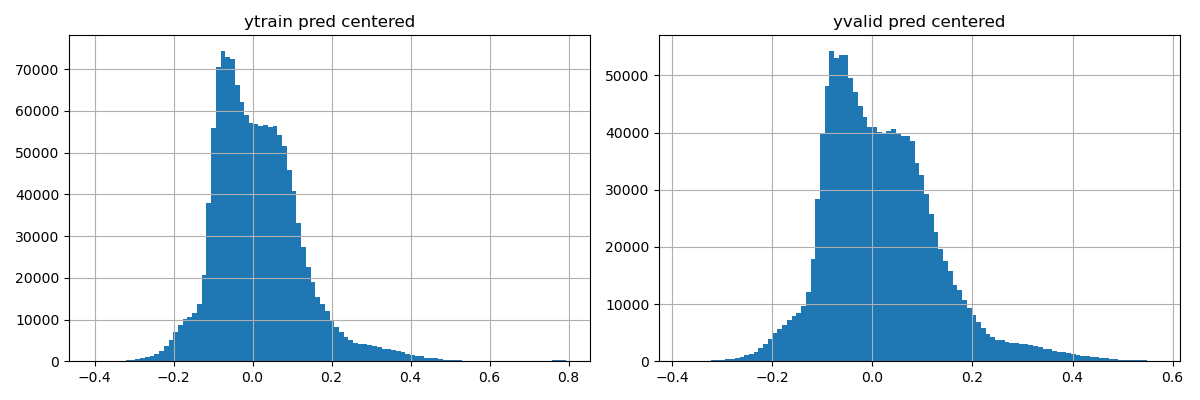

In [10]:
central = plotHistogram(model, X_norm, X_valid_norm, centralize=True)

In [11]:
ypred_train = model.predict(X_norm)
ypred_valid = model.predict(X_valid_norm)
central     = np.median(ypred_train)
ypred_train = binToDirectionY(ypred_train, central)
ypred_valid = binToDirectionY(ypred_valid, central)

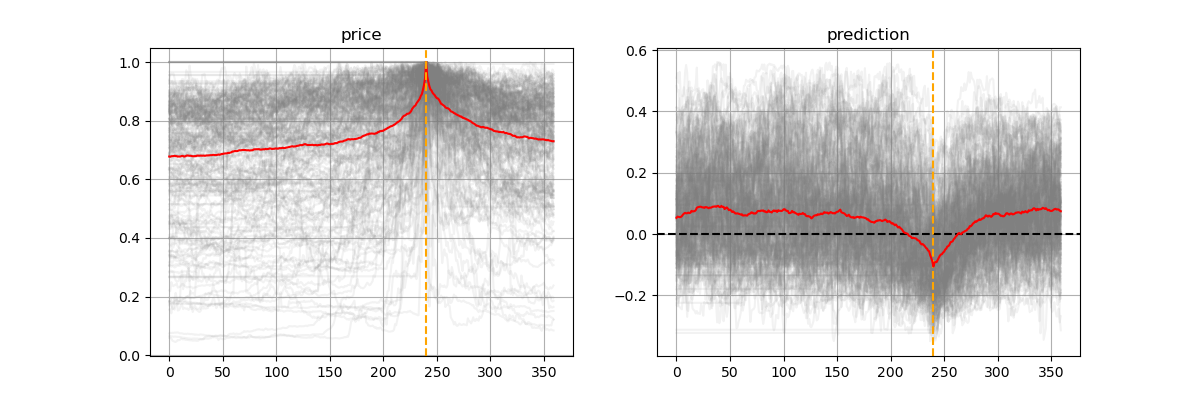

In [12]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_train, O)
showPricePred(price_mat, pred_mat)

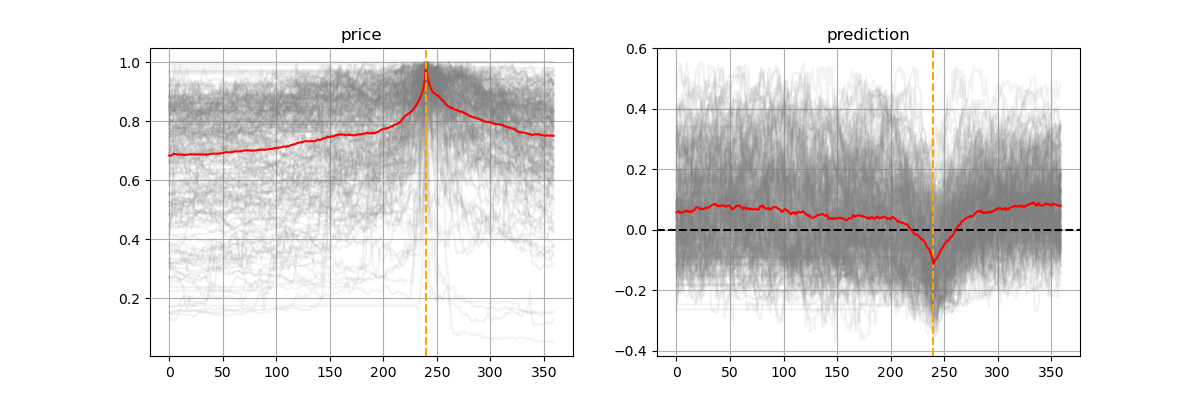

In [13]:
price_mat, pred_mat, *_ = tb.peakPredProfiles(ypred_valid, O_valid)
showPricePred(price_mat, pred_mat)

## Positive Prediction

In [14]:
def shiftY(y, pivot, steep):
    return sigmoid((y-pivot)/steep)

def binaryLabel(y, cutoff = 0):
    return 1.0*(y > cutoff)

In [38]:
params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",          # gbdt, dart, or goss
    "scale_pos_weight": 50.0,

    "num_leaves": 63,                  # max leaves per tree (main control of complexity)
    "max_depth": 4,                    # -1 = no limit; sometimes useful to cap
    "min_child_samples": 100,           # min data points in a leaf

    "learning_rate": 0.01,
    "n_estimators": 200,              # or use num_boost_round in lgb.train()

    "subsample": 0.6,                  # row sampling per tree
    "subsample_freq": 1,               # apply subsample every N iterations (1 = every tree)
    "colsample_bytree": 0.6,           # feature sampling per tree
    "colsample_bynode": 1.0,           # feature sampling per split
    
    "num_threads": -1,                 # -1 = use all cores

    "early_stopping_rounds": 50,       # stop if no improvement for N rounds
    "verbose" : 0,
}

In [39]:
Yshift = binaryLabel(Y['ret_24h'].values, 0.2)
pos_ratio = np.sum(Yshift)/(Yshift.shape[0] - np.sum(Yshift))
pos_ratio

np.float64(0.010721771547214437)

In [40]:
params['scale_pos_weight'] = 1.0/pos_ratio
model_binary, loss_path = tb.fitLgb(X_norm, Yshift,  params, log_period=100)

[100]	train's binary_logloss: 0.291221	train's auc: 0.828678	val's binary_logloss: 0.291221	val's auc: 0.828678
[200]	train's binary_logloss: 0.414989	train's auc: 0.831777	val's binary_logloss: 0.414989	val's auc: 0.831777


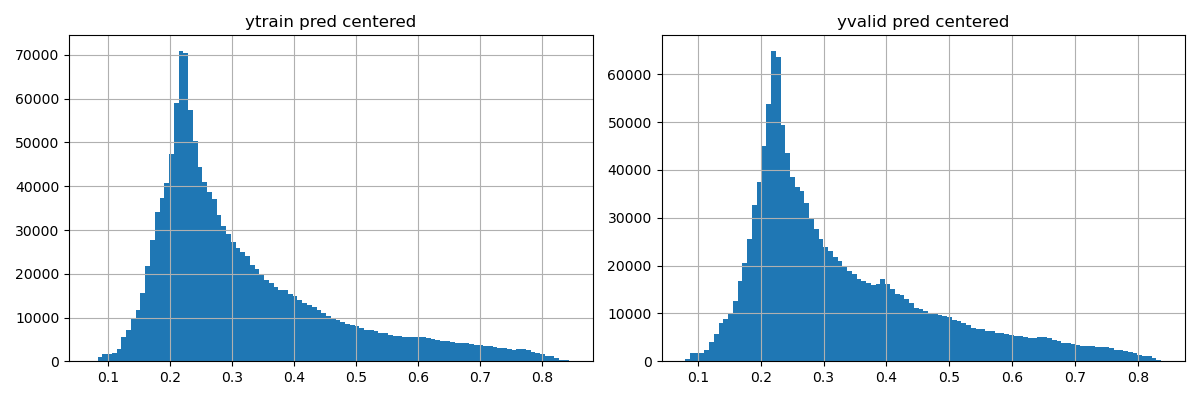

In [41]:
central = plotHistogram(model_binary, X_norm, X_valid_norm, centralize=False)

In [42]:
ypred_train = model_binary.predict(X_norm)
ypred_valid = model_binary.predict(X_valid_norm)

In [43]:
valid_long_short = tb.causal_long_short(np.where(ypred_valid > 0.80, 1.0, 0.0), O_valid)
train_long_short = tb.causal_long_short(np.where(ypred_train > 0.80, 1.0, 0.0), O)

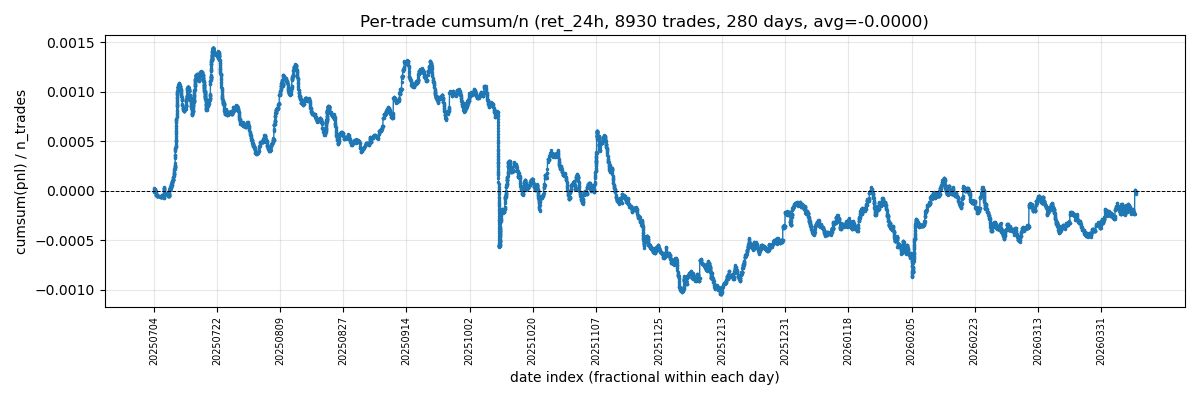

In [44]:
_ = tb.plotDailyReturnExactTrades(valid_long_short, Y_valid, O_valid, horizon='ret_24h')

In [51]:
long_valid = model_binary.predict(X_valid_norm)
long_signal = tb.causal_long_short(np.where(long_valid > 0.80, 1.0, 0.0), O_valid)

ypred_train = model.predict(X_norm)
short_valid = model.predict(X_valid_norm)
central     = np.median(ypred_train)
short_valid = binToDirectionY(short_valid, central)
short_signal = (ypred_valid < -0.1)*(-1.0)

In [52]:
out = tb.long_short_tradeReturn(long_signal, short_signal, O_valid, stoploss=0.10,   min_horizon=24,   max_horizon=48) 

In [53]:
out

,ticker,startTime,endTime,priceStart,priceEnd,return,date,duration
0,AERGOUSDT,2025-12-13 14:00:00,2025-12-15 02:00:00,0.06500,0.05830,-0.103077,20251213,36.0
1,AERGOUSDT,2025-12-18 11:00:00,2025-12-20 11:00:00,0.07053,0.06612,-0.062527,20251218,48.0
2,AINUSDT,2025-08-07 09:00:00,2025-08-09 09:00:00,0.11639,0.11803,0.014091,20250807,48.0
3,AINUSDT,2025-08-09 18:00:00,2025-08-11 18:00:00,0.14738,0.14180,-0.037861,20250809,48.0
4,AINUSDT,2025-08-28 12:00:00,2025-08-30 12:00:00,0.11808,0.12018,0.017785,20250828,48.0
...,...,...,...,...,...,...,...,...
284,ZEREBROUSDT,2025-12-02 02:00:00,2025-12-02 04:00:00,0.03409,0.03055,-0.103843,20251202,2.0
285,ZILUSDT,2026-02-02 17:00:00,2026-02-04 17:00:00,0.00523,0.00540,0.032505,20260202,48.0
286,ZILUSDT,2026-02-08 08:00:00,2026-02-08 21:00:00,0.00502,0.00450,-0.103586,20260208,13.0
287,ZKJUSDT,2025-08-10 11:00:00,2025-08-11 10:00:00,0.29350,0.26110,-0.110392,20250810,23.0


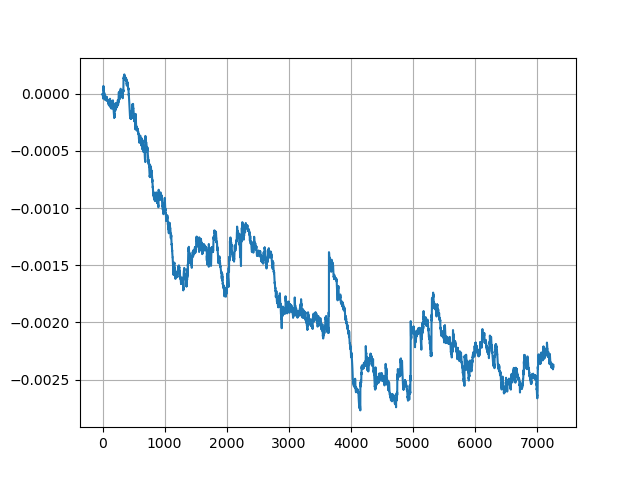

In [48]:
plt.figure()
plt.plot(np.cumsum(out['return'].values)/out.shape[0])
plt.grid(True)

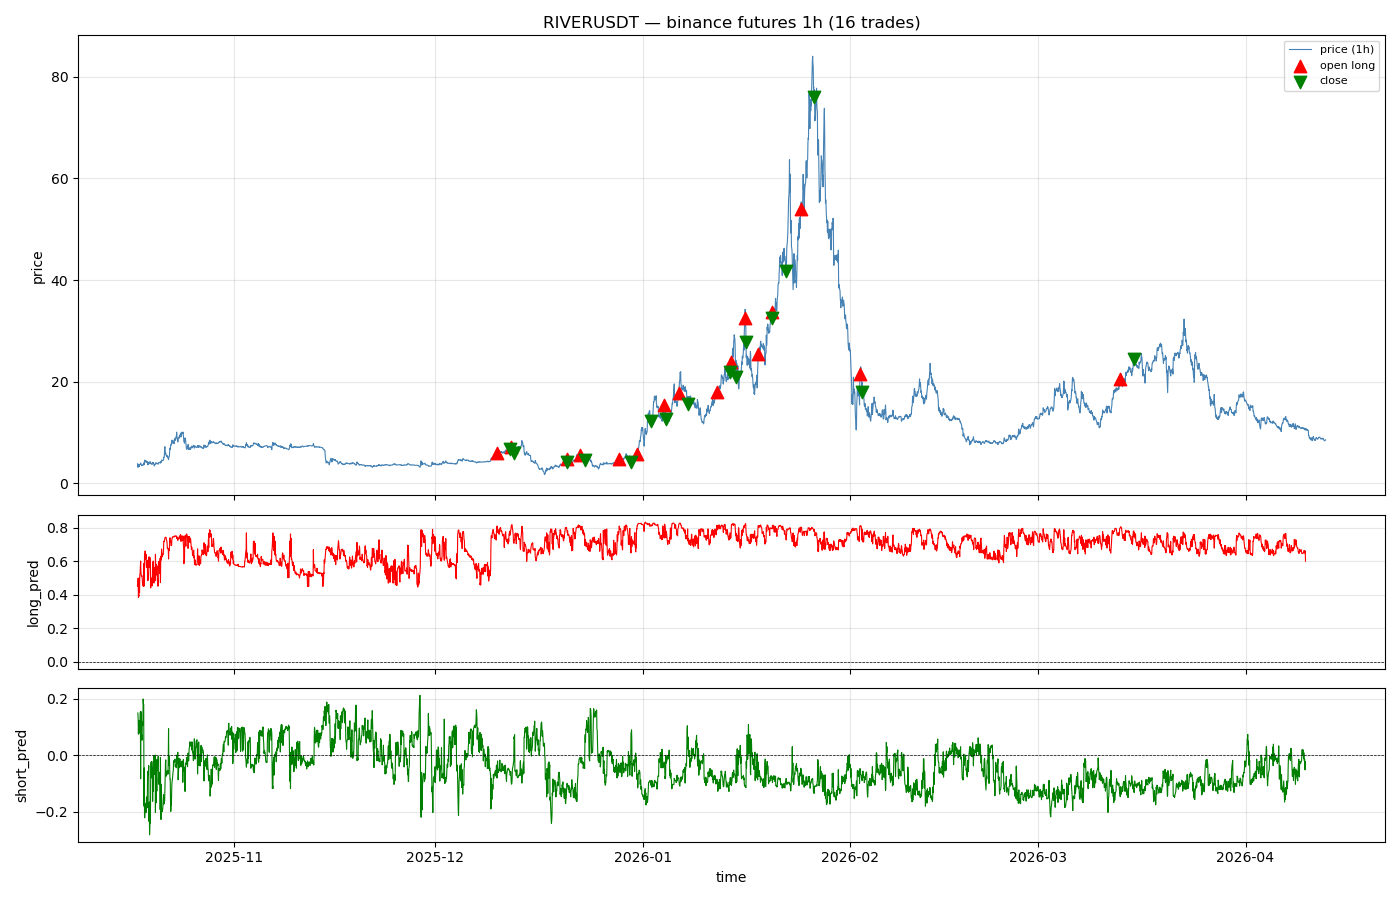

In [55]:
tb.showTrade(dl, out, 'RIVERUSDT', long_pred= long_valid, short_pred = short_valid, O = O_valid)